# Hodgkin Huxley neuron

[![Download JupyterNotebook](https://img.shields.io/badge/Download-Notebook-orange?style=for-the-badge&logo=Jupyter)](https://raw.githubusercontent.com/ANNarchy/ANNarchy.github.io/master/notebooks/HodgkinHuxley.ipynb) [![Download JupyterNotebook](https://img.shields.io/badge/Open_in-Colab-blue?style=for-the-badge&logo=Jupyter)](https://colab.research.google.com/github/ANNarchy/ANNarchy.github.io/blob/master/notebooks/HodgkinHuxley.ipynb)

In [1]:
#!pip install ANNarchy

Simple Hodgkin-Huxley neuron.

ANNarchy 5.0 (5.0.1) on linux (posix).


Compiling network 1... 

OK


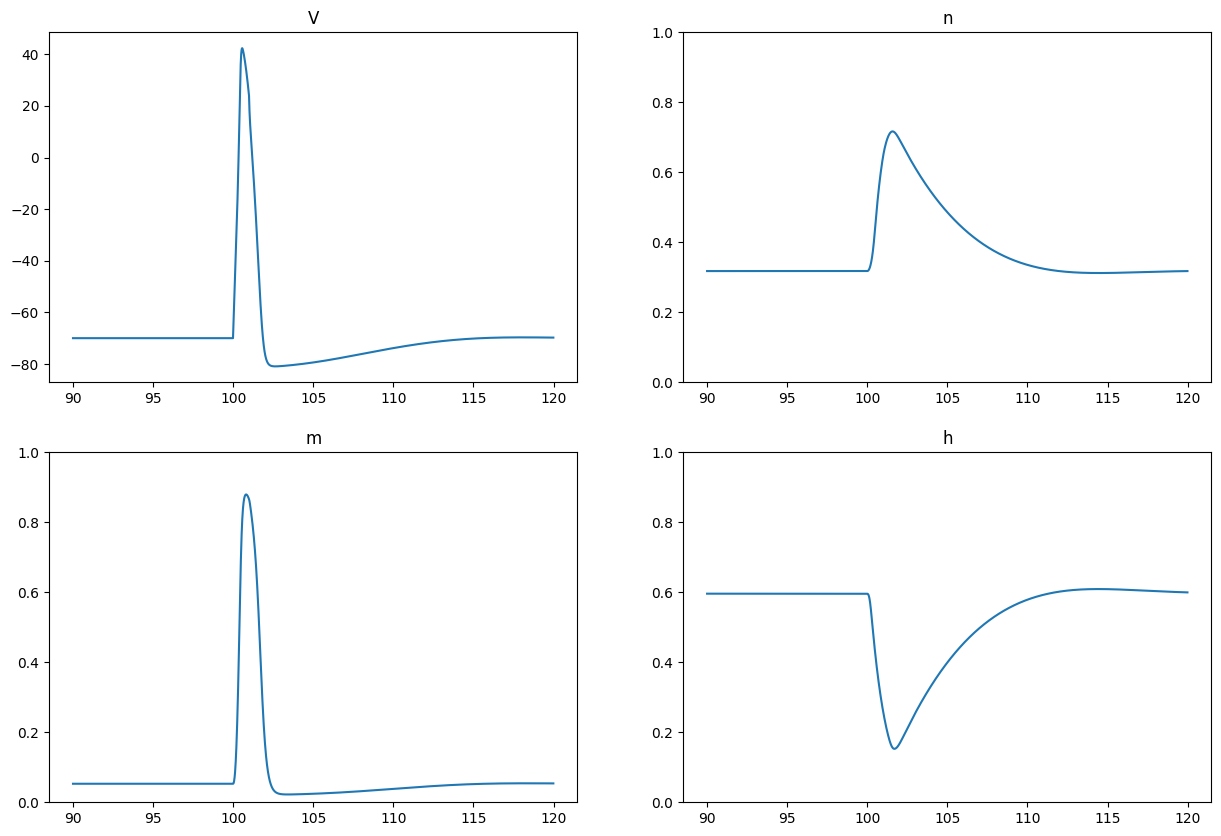

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ANNarchy as ann

HH = ann.Neuron(

    parameters = dict(
        C = 1.0, # Capacitance
        VL = -59.387, # Leak voltage
        VK = -82.0, # Potassium reversal voltage
        VNa = 45.0, # Sodium reveral voltage
        gK = 36.0, # Maximal Potassium conductance
        gNa = 120.0, # Maximal Sodium conductance
        gL = 0.3, # Leak conductance
        vt = 30.0, # Threshold for spike emission
        I = 0.0, # External current
    ),

    equations = [
        # Previous membrane potential
        'prev_V = V',

        # Voltage-dependency parameters
        """
        an = 0.01 * (V + 60.0) / (1.0 - exp(-0.1* (V + 60.0) ) )
        am = 0.1 * (V + 45.0) / (1.0 - exp (- 0.1 * ( V + 45.0 )))
        ah = 0.07 * exp(- 0.05 * ( V + 70.0 ))

        bn = 0.125 * exp (- 0.0125 * (V + 70.0))
        bm = 4.0 *  exp (- (V + 70.0) / 80.0)
        bh = 1.0/(1.0 + exp (- 0.1 * ( V + 40.0 )) )
        """,

        # Alpha/Beta functions
        ann.Variable('dn/dt = an * (1.0 - n) - bn * n', init = 0.3, method='midpoint'),
        ann.Variable('dm/dt = am * (1.0 - m) - bm * m', init = 0.0, method='midpoint'),
        ann.Variable('dh/dt = ah * (1.0 - h) - bh * h', init = 0.6, method='midpoint'),

        # Membrane equation
        ann.Variable('C * dV/dt = gL * (VL - V ) + gK * n**4 * (VK - V) + gNa * m**3 * h * (VNa - V) + I', method='midpoint'),
    ],

    spike = """
        # Spike is emitted when the membrane potential crosses the threshold from below
        (V > vt) and (prev_V <= vt)    
    """,

    reset = """
        # Nothing to do, it is built-in...
    """
)

net = ann.Network(dt=0.01)

pop = net.create(neuron=HH, geometry=1)
pop.V = -50.0

net.compile()

m = net.monitor(pop, ['spike', 'V', 'n', 'm', 'h'])

# Preparation
net.simulate(100.0)
# Current impulse for 1 ms
pop.I = 200.0
net.simulate(1.0)
# Reset
pop.I = 0.0
net.simulate(100.0)

data = m.get()

tstart = int(90.0/net.dt)
tstop  = int(120.0/net.dt)

plt.figure(figsize=(15, 10))
plt.subplot(2,2,1)
plt.plot(90.0 + net.dt*np.arange(tstop-tstart), data['V'][tstart:tstop, 0])
plt.title('V')
plt.subplot(2,2,2)
plt.plot(90.0 + net.dt*np.arange(tstop-tstart), data['n'][tstart:tstop, 0])
plt.title('n')
plt.ylim((0.0, 1.0))
plt.subplot(2,2,3)
plt.plot(90.0 + net.dt*np.arange(tstop-tstart), data['m'][tstart:tstop, 0])
plt.title('m')
plt.ylim((0.0, 1.0))
plt.subplot(2,2,4)
plt.plot(90.0 + net.dt*np.arange(tstop-tstart), data['h'][tstart:tstop, 0])
plt.title('h')
plt.ylim((0.0, 1.0))
plt.show()